In [1]:
import os
import pandas as pd
import matplotlib.pylab as plt

In [2]:
plt.style.use('ggplot')           # или 'default', 'bmh', 'seaborn-v0_8' и др.
plt.rcParams['figure.figsize'] = (14, 3.8)   # ширина × высота одной фигуры
metric_list = [['loss', 'val_loss'], ['precision', 'v_precision'], ['recall', 'v_recall']]

In [3]:
def show_results(df:pd.DataFrame, metric_list:list, name:str) -> None:
    num_plots = len(metric_list)
    fig, axes = plt.subplots(1, num_plots, figsize=(16, 4), sharex=True)
    for i, metric in enumerate(metric_list):
        axes[i].plot(df['epoch'][3:], df[metric[0]][3:], label='train')
        axes[i].plot(df['epoch'][3:], df[metric[1]][3:], label='val')
        axes[i].set_title(metric[0])
        axes[i].set_xlabel('Epoch')
        axes[i].set_ylabel(metric[0])
        axes[i].legend()
        axes[i].grid(linewidth=0.8, linestyle='--', alpha=0.7)
    fig.suptitle(f'Метрики во время обучения\n{name}', fontsize=16, y=1.02)
    # Чтобы подписи не налезали друг на друга
    plt.tight_layout()
    plt.show()


def vis_data_results(path:str|list[str], metric_list:list):
    if type(path) == list:
        for csv_path in path:
            name = csv_path.split('/')[-3]
            try:
                train_df = pd.read_csv(csv_path)
                show_results(train_df, metric_list, name)
            except Exception as e:
                print(f"{e}:\n{csv_path}\n")
    else:
        name = path.split('/')[-3]
        train_df = pd.read_csv(csv_path)
        show_results(train_df, metric_list, name)

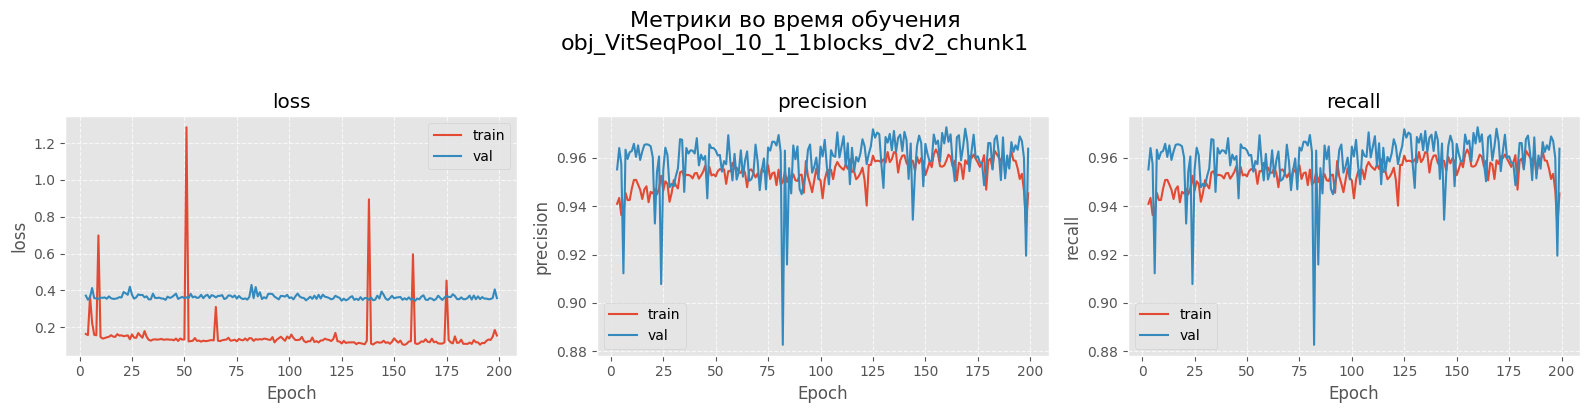

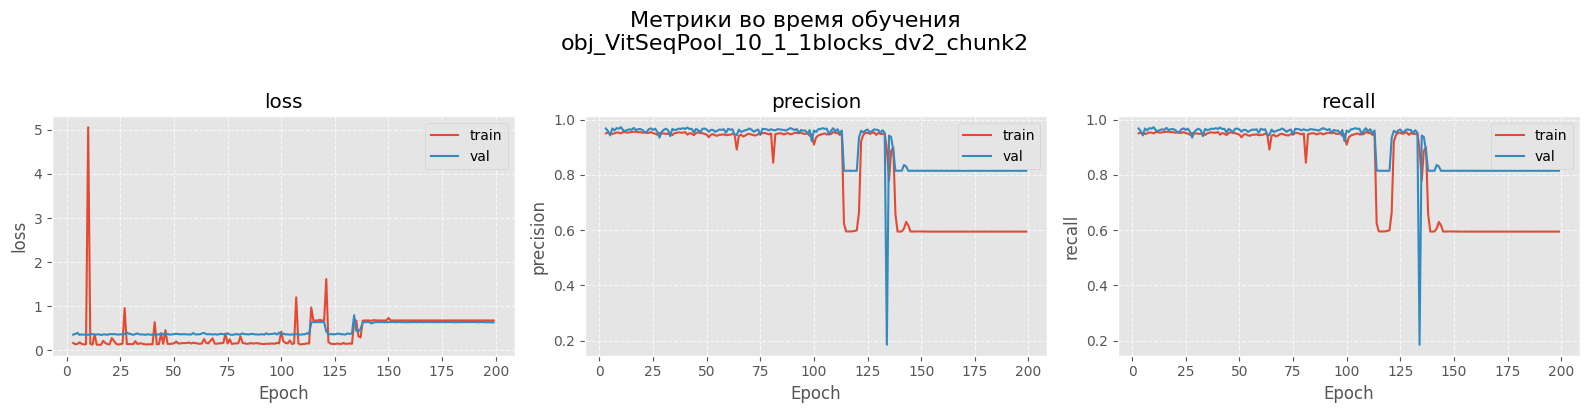

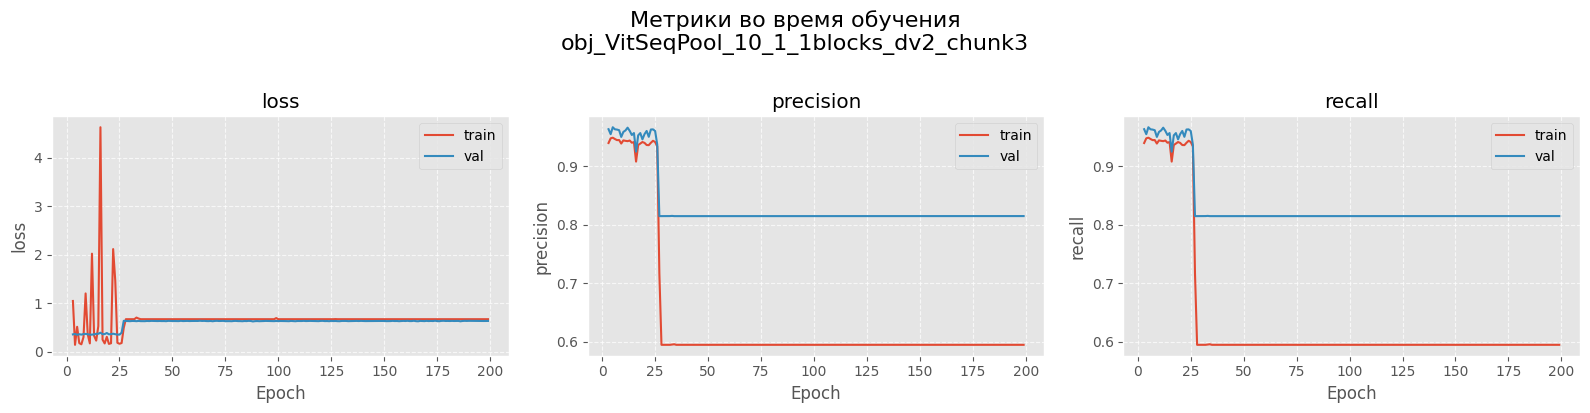

In [20]:
path_list  = [
    "runs/sequense_cls/v2/obj_VitSeqPool_10_1_1blocks_dv2_chunk1/logs/logs.csv",
    "runs/sequense_cls/v2/obj_VitSeqPool_10_1_1blocks_dv2_chunk2/logs/logs.csv",
    "runs/sequense_cls/v2/obj_VitSeqPool_10_1_1blocks_dv2_chunk3/logs/logs.csv",
]
for path in path_list:
    name = path.split('/')[-3]
    train_df = pd.read_csv(path)
    show_results(train_df, metric_list, name)

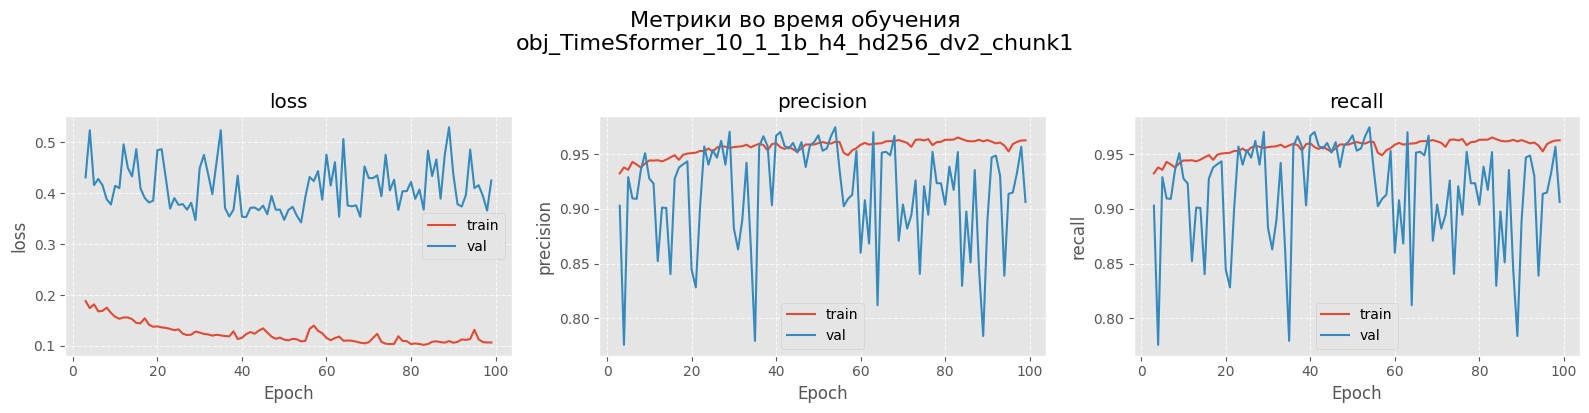

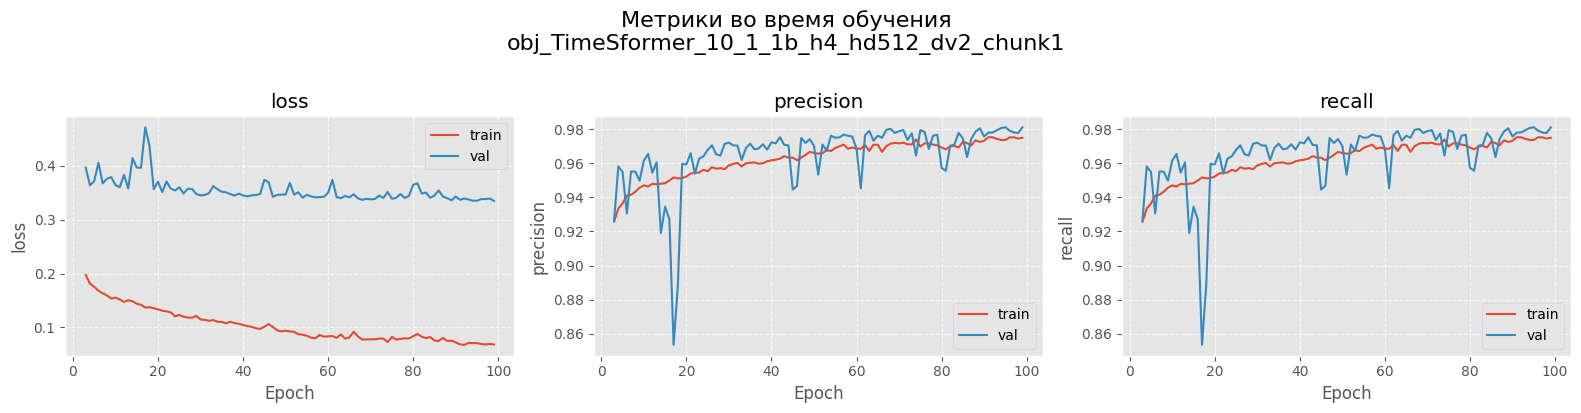

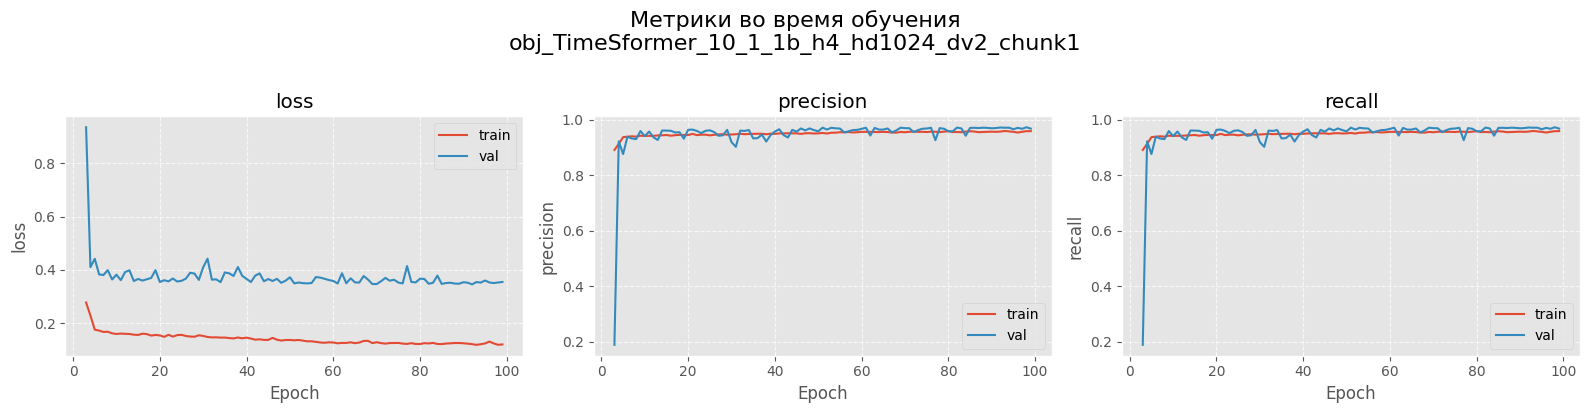

In [5]:
path_list = [
    "runs/sequense_cls/v2/obj_TimeSformer_10_1_1b_h4_hd256_dv2_chunk1/logs/logs.csv",
    "runs/sequense_cls/v2/obj_TimeSformer_10_1_1b_h4_hd512_dv2_chunk1/logs/logs.csv",
    "runs/sequense_cls/v2/obj_TimeSformer_10_1_1b_h4_hd1024_dv2_chunk1/logs/logs.csv",
]
vis_data_results(path_list, metric_list)